In [1]:
!pip install pandas numpy scikit-learn xgboost plotly explicit

   ---------------------------------------- 0.0/48.9 MB ? eta -:--:--
   ---------------------------------------- 0.0/48.9 MB ? eta -:--:--
   ---------------------------------------- 0.5/48.9 MB 1.5 MB/s eta 0:00:32
    --------------------------------------- 0.8/48.9 MB 1.5 MB/s eta 0:00:33
    --------------------------------------- 1.0/48.9 MB 1.4 MB/s eta 0:00:35
   - -------------------------------------- 1.3/48.9 MB 1.4 MB/s eta 0:00:35
   - -------------------------------------- 1.6/48.9 MB 1.4 MB/s eta 0:00:35
   - -------------------------------------- 1.8/48.9 MB 1.4 MB/s eta 0:00:34
   - -------------------------------------- 2.1/48.9 MB 1.4 MB/s eta 0:00:34
   - -------------------------------------- 2.4/48.9 MB 1.4 MB/s eta 0:00:34
   -- ------------------------------------- 2.9/48.9 MB 1.4 MB/s eta 0:00:33
   -- ------------------------------------- 3.1/48.9 MB 1.4 MB/s eta 0:00:33
   -- ------------------------------------- 3.4/48.9 MB 1.4 MB/s eta 0:00:33
   -- -------

In [2]:
import pandas as pd
import numpy as np
import joblib

# Machine Learning & Pipelines
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.metrics import classification_report, roc_auc_score
from xgboost import XGBClassifier

# Visualization
import plotly.express as px
import plotly.graph_objects as go

# Configurations
import warnings
warnings.filterwarnings('ignore')

In [4]:
df = pd.read_csv('Telco-Customer-Churn.csv')
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [6]:
df.shape

(7043, 21)

In [8]:
# 1. Clean the TotalCharges column (Fixes the string-space anomaly)
# This forces empty spaces to NaN and sets them to 0.0 for new customers
df_clean = df.copy()  # Assuming your loaded dataframe is named 'df'
df_clean['TotalCharges'] = pd.to_numeric(df_clean['TotalCharges'].str.strip(), errors='coerce').fillna(0)

# 2. Encode the Target variable to binary numbers (Yes -> 1, No -> 0)
df_clean['Churn'] = df_clean['Churn'].map({'Yes': 1, 'No': 0})

# 3. Drop the customerID column since it is just an arbitrary text label
if 'customerID' in df_clean.columns:
    df_clean = df_clean.drop(columns=['customerID'])

# 4. Isolate features (X) and target label (y)
X = df_clean.drop(columns=['Churn'])
y = df_clean['Churn']

# 5. Group features by type for the next step
numerical_features = ['tenure', 'MonthlyCharges', 'TotalCharges']
categorical_features = [col for col in X.columns if col not in numerical_features]

print(f"✅ Data cleaning pipeline applied directly to your loaded variable!")
print(f"Cleaned dataset shape: {df_clean.shape}")

✅ Data cleaning pipeline applied directly to your loaded variable!
Cleaned dataset shape: (7043, 20)


In [9]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer

# 1. Stratified Split (80% Train, 20% Test)
# 'stratify=y' ensures both sets have the exact same percentage of churned users!
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# 2. Build the Preprocessing Engine
# StandardScaler: normalizes numeric scales (tenure, charges)
# OneHotEncoder: converts text categories (e.g., Contract types) into 1s and 0s
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numerical_features),
        ('cat', OneHotEncoder(handle_unknown='ignore', drop='first'), categorical_features)
    ]
)

# 3. Process the data (Fit on training data ONLY to prevent data leakage)
X_train_transformed = preprocessor.fit_transform(X_train)
X_test_transformed = preprocessor.transform(X_test)

print("📦 Data split and transformed successfully!")
print(f"Training Matrix Shape: {X_train_transformed.shape}")
print(f"Testing Matrix Shape: {X_test_transformed.shape}")

📦 Data split and transformed successfully!
Training Matrix Shape: (5634, 30)
Testing Matrix Shape: (1409, 30)


In [10]:
from xgboost import XGBClassifier
from sklearn.metrics import classification_report, roc_auc_score

# 1. Initialize the XGBoost Classifier
# We set max_depth and learning_rate to solid baseline values to prevent overfitting.
xgb_model = XGBClassifier(
    n_estimators=150,
    max_depth=4,
    learning_rate=0.08,
    random_state=42,
    eval_metric='logloss'
)

# 2. Train the model on the transformed training data
print("🏋️‍♂️ Training the XGBoost model...")
xgb_model.fit(X_train_transformed, y_train)

# 3. Generate predictions and probability scores using the test data
y_pred = xgb_model.predict(X_test_transformed)
y_prob = xgb_model.predict_proba(X_test_transformed)[:, 1]

# 4. Print professional evaluation metrics
print("\n=== 📊 Model Performance Evaluation ===")
print(f"ROC-AUC Score: {roc_auc_score(y_test, y_prob):.4f}")
print("-" * 45)
print(classification_report(y_test, y_pred, target_names=['Retained (0)', 'Churned (1)']))

🏋️‍♂️ Training the XGBoost model...

=== 📊 Model Performance Evaluation ===
ROC-AUC Score: 0.8444
---------------------------------------------
              precision    recall  f1-score   support

Retained (0)       0.84      0.90      0.87      1035
 Churned (1)       0.65      0.52      0.57       374

    accuracy                           0.80      1409
   macro avg       0.74      0.71      0.72      1409
weighted avg       0.79      0.80      0.79      1409



In [11]:
import joblib

# 1. Save the model and the preprocessor so you can use them later without retraining
joblib.dump(xgb_model, "xgb_churn_model.pkl")
joblib.dump(preprocessor, "preprocessor.pkl")
print("💾 Model and Preprocessor successfully saved to your local directory!")

# 2. Build the Live Inference Engine Function
def predict_single_customer(customer_profile: dict) -> None:
    """Takes a raw dictionary profile, processes it, and returns the real-time churn risk."""
    # Load the saved tools
    loaded_model = joblib.load("xgb_churn_model.pkl")
    loaded_preprocessor = joblib.load("preprocessor.pkl")
    
    # Convert the single dictionary entry into a Pandas DataFrame row
    input_df = pd.DataFrame([customer_profile])
    
    # Run the customer profile through the same preprocessing pipeline
    processed_input = loaded_preprocessor.transform(input_df)
    
    # Calculate the exact probability of churn
    churn_probability = loaded_model.predict_proba(processed_input)[0, 1]
    
    # Output the business decision
    print("\n" + "="*45)
    print("🔮 REAL-TIME CHURN INFRASTRUCTURE OUTPUT")
    print("="*45)
    print(f"Customer Churn Probability: {churn_probability:.2%}")
    
    if churn_probability >= 0.50:
        print("🚨 STATUS: HIGH RISK. Trigger retention discount offer.")
    else:
        print("✅ STATUS: STABLE. Normal operations.")
    print("="*45)

# 3. MOCK LIVE CUSTOMER TEST CASE
# You can change these values right here in the notebook to test different customer behaviors!
test_customer = {
    'gender': 'Female', 'SeniorCitizen': 1, 'Partner': 'No', 'Dependents': 'No',
    'tenure': 2,  # Brand new customer (High Risk)
    'PhoneService': 'Yes', 'MultipleLines': 'No', 'InternetService': 'Fiber optic',
    'OnlineSecurity': 'No', 'OnlineBackup': 'No', 'DeviceProtection': 'No', 'TechSupport': 'No',
    'StreamingTV': 'Yes', 'StreamingMovies': 'Yes',
    'Contract': 'Month-to-month',  # No contract lock-in (High Risk)
    'PaperlessBilling': 'Yes', 'PaymentMethod': 'Electronic check',
    'MonthlyCharges': 89.50, 'TotalCharges': 179.00
}

# Run the inference
predict_single_customer(test_customer)

💾 Model and Preprocessor successfully saved to your local directory!

🔮 REAL-TIME CHURN INFRASTRUCTURE OUTPUT
Customer Churn Probability: 74.89%
🚨 STATUS: HIGH RISK. Trigger retention discount offer.


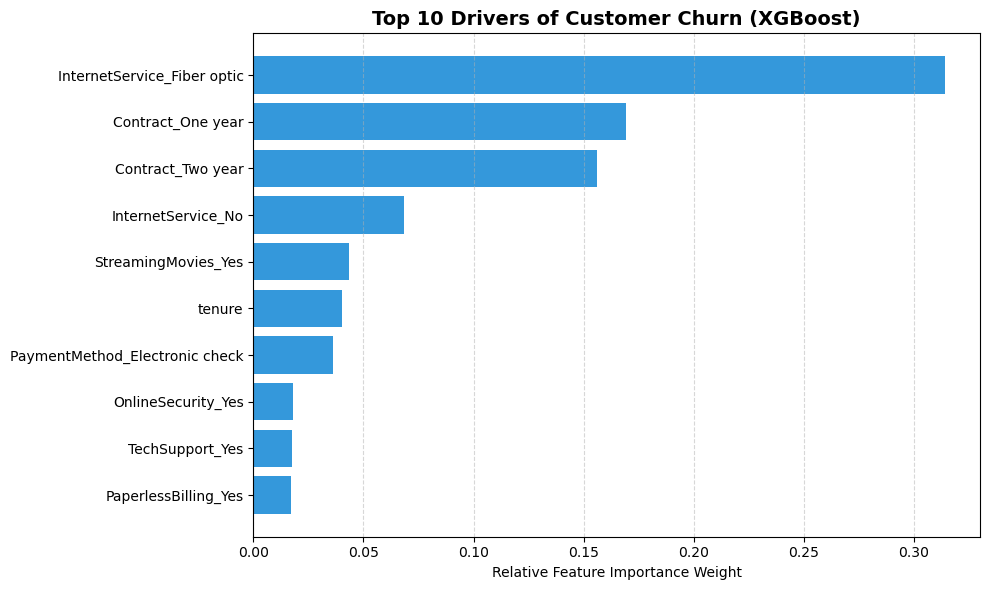

In [12]:
import matplotlib.pyplot as plt

# 1. Extract the engineered feature names from the categorical encoder step
# This maps the transformed numbers back to their actual readable column labels
cat_encoder = preprocessor.named_transformers_['cat']
encoded_cat_features = list(cat_encoder.get_feature_names_out(categorical_features))

# Combine numerical names with the freshly encoded categorical column names
all_features = numerical_features + encoded_cat_features

# 2. Extract weights directly from your trained model and pair them with feature names
importance_df = pd.DataFrame({
    'Feature': all_features,
    'Importance': xgb_model.feature_importances_
}).sort_values(by='Importance', ascending=False)

# 3. Render a clean horizontal bar plot of the Top 10 most impactful features
plt.figure(figsize=(10, 6))
plt.barh(importance_df['Feature'].head(10)[::-1], importance_df['Importance'].head(10)[::-1], color='#3498db')
plt.xlabel('Relative Feature Importance Weight')
plt.title('Top 10 Drivers of Customer Churn (XGBoost)', fontsize=14, fontweight='bold')
plt.grid(axis='x', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()